Cheryl Eugene Saari 
NIM: 2802434844

# Dimension Reduction dengan Autoencoder — Overhead-MNIST (Ship)

[LO 1, LO 2, LO 3 & LO 4, 30 poin] DJ Patil dikenal sebagai data scientist. Ia ingin melakukan **Dimension Reduction** dari dua kelas citra (kelas `ship1 pada dataset [Overhead-MNIST](https://www.kaggle.com/datasets/datamunge/overheadmnist/data)) dengan menggunakan algoritma **Autoencoder** secara optimal.

**Struktur notebook ini:**
1. Import library
2. **(a)** Loading data, pengecekan duplikat, scaling, contoh data, split 80/10/10
3. **(b)** Arsitektur baseline Autoencoder (sesuai diagram) + evaluasi SSIM/PSNR/MSE
4. **(c)** Arsitektur improved + tuning hyperparameter + perbandingan SSIM
5. **(d)** Catatan untuk video presentasi

## 1. Import Library

In [1]:
import os
import glob
import json
import hashlib
import itertools

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image

# Reproducibility
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
import random
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

IMG_SIZE = 28
LATENT_DIM = 128          # dimensi latent sesuai diagram soal (784 -> 128)
CLASSES = ['ship']

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

2026-06-27 15:35:08.928636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782574509.104646      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782574509.157292      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782574509.585388      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782574509.585440      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782574509.585443      58 computation_placer.cc:177] computation placer alr

## 2. (a) Loading & Preprocessing Data

### 2.1 Konfigurasi path dataset

In [2]:
DATASET_ROOT = '/kaggle/input/datasets/datamunge/overheadmnist/version2'

# Path untuk tiap kelas x tiap split bawaan kaggle (training/testing)
CLASS_DIRS = {
    cls: {
        'training': f'{DATASET_ROOT}/train/{cls}',
        'testing':  f'{DATASET_ROOT}/test/{cls}',
    }
    for cls in CLASSES
}

CLASS_DIRS

{'ship': {'training': '/kaggle/input/datasets/datamunge/overheadmnist/version2/train/ship',
  'testing': '/kaggle/input/datasets/datamunge/overheadmnist/version2/test/ship'}}

### 2.2 Load seluruh gambar (training + testing digabung)

In [3]:
def load_images_from_dir(folder, label, img_size=IMG_SIZE):
    # Ambil semua file gambar di folder (jpg/jpeg/png, huruf besar/kecil)
    patterns = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    filepaths = []
    for p in patterns:
        filepaths.extend(glob.glob(os.path.join(folder, p)))
    filepaths = sorted(filepaths)

    images, labels = [], []
    for fp in filepaths:
        img = Image.open(fp).convert('L').resize((img_size, img_size))
        images.append(np.array(img, dtype='uint8'))
        labels.append(label)
    return images, labels


def load_all_classes(class_dirs, classes):
    all_images, all_labels = [], []
    for label, cls in enumerate(classes):
        for split_name, folder in class_dirs[cls].items():
            imgs, lbls = load_images_from_dir(folder, label)
            all_images.extend(imgs)
            all_labels.extend(lbls)
            print(f"  {cls:<12} [{split_name:<8}] -> {len(imgs)} gambar  (label={label})")
    return np.array(all_images, dtype='uint8'), np.array(all_labels, dtype='int64')


print("Loading & menggabungkan seluruh data (training + testing) per kelas...")
X_raw, y = load_all_classes(CLASS_DIRS, CLASSES)
print(f"\nTotal gambar gabungan : {X_raw.shape[0]}")
print(f"Shape per gambar      : {X_raw.shape[1:]}")
print(f"Distribusi kelas      : {dict(zip(*np.unique(y, return_counts=True)))}")

Loading & menggabungkan seluruh data (training + testing) per kelas...
  ship         [training] -> 7124 gambar  (label=0)
  ship         [testing ] -> 888 gambar  (label=0)

Total gambar gabungan : 8012
Shape per gambar      : (28, 28)
Distribusi kelas      : {np.int64(0): np.int64(8012)}


**Interpretasi:** gambar / data dari training dan testing berhasil di load semua dan digabung menjadi 1. 

### 2.3 Pengecekan Data Duplikat

Karena ini data gambar (bukan tabel), pengecekan duplikat dilakukan dengan **hashing** isi piksel tiap gambar (`MD5` dari array piksel); dua gambar dianggap duplikat persis jika hash-nya identik.

In [4]:
def find_duplicate_indices(images):
    seen_hash = {}
    duplicate_idx = []
    for i, img in enumerate(images):
        h = hashlib.md5(img.tobytes()).hexdigest()
        if h in seen_hash:
            duplicate_idx.append(i)
        else:
            seen_hash[h] = i
    return duplicate_idx


duplicate_idx = find_duplicate_indices(X_raw)
n_dup = len(duplicate_idx)
print(f"Jumlah gambar duplikat terdeteksi : {n_dup} dari {len(X_raw)} ({n_dup/len(X_raw)*100:.2f}%)")

if n_dup > 0:
    keep_mask = np.ones(len(X_raw), dtype=bool)
    keep_mask[duplicate_idx] = False
    X_raw, y = X_raw[keep_mask], y[keep_mask]
    print(f"Duplikat dihapus (menyisakan kemunculan pertama). Total gambar sekarang: {len(X_raw)}")
else:
    print("Tidak ditemukan duplikat persis -> lanjut ke tahap scaling tanpa perlu menghapus data.")

Jumlah gambar duplikat terdeteksi : 12 dari 8012 (0.15%)
Duplikat dihapus (menyisakan kemunculan pertama). Total gambar sekarang: 8000


**Interpretasi:** terdapat 12 duplicate data, dan langsung dihapus duplicatenya sehingga total data kita ada 8000.

### 2.4 Scaling Data

**Alasan:** nilai piksel mentah berada di rentang `[0, 255]`. Untuk training neural network, terutama dengan output decoder yang memakai activation `sigmoid` (dimana hasilnya selalu di rentang `[0, 1]`), maka input harus diskalakan ke rentang yang sama (`[0, 1]`) supaya loss `binary_crossentropy` antara input asli dan hasil rekonstruksi bisa dihitung secara konsisten.

Scaling dilakukan dengan membagi setiap nilai piksel dengan `255.0`, lalu data di-reshape menjadi `(jumlah_sampel, 28, 28, 1)` — dimensi channel `1` ditambahkan karena layer `Conv2D` di Keras mengharapkan input 4D `(batch, height, width, channel)`.

In [5]:
X = X_raw.astype('float32') / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(f"Shape akhir X         : {X.shape}")
print(f"Range nilai piksel    : [{X.min():.3f}, {X.max():.3f}]")
print(f"dtype                 : {X.dtype}")

Shape akhir X         : (8000, 28, 28, 1)
Range nilai piksel    : [0.000, 1.000]
dtype                 : float32


### 2.5 Contoh Data (Setelah Scaling)

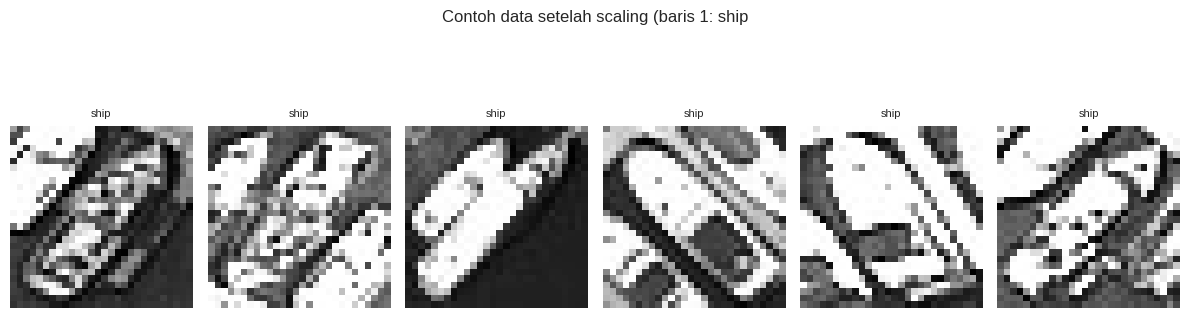

In [6]:
plt.figure(figsize=(12, 4))
n_per_class = 6
for lbl, cls in enumerate(CLASSES):
    idx = np.where(y == lbl)[0][:n_per_class]
    for j, k in enumerate(idx):
        plt.subplot(len(CLASSES), n_per_class, lbl * n_per_class + j + 1)
        plt.imshow(X[k].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title(cls, fontsize=8)
        plt.axis('off')
plt.suptitle("Contoh data setelah scaling (baris 1: ship")
plt.tight_layout()
plt.show()

### 2.6 Split Data: 80% Train / 10% Validation / 10% Test

**Alasan teknik split dua tahap:** `train_test_split` dari sklearn hanya bisa membagi data jadi 2 bagian sekali panggil, sehingga untuk mendapatkan 3 bagian (train/val/test) kita panggil dua kali secara berurutan:

1. Pisahkan **10% test** dari keseluruhan data (`test_size=0.10`) → sisa 90% (`x_tmp`).
2. Dari sisa 90% itu, pisahkan lagi validation set sebesar **`0.1111 × 90% ≈ 10%`** dari total data awal → sisanya jadi train set (`≈ 80%` dari total).

`stratify=y` dipakai di kedua tahap supaya proporsi kelas `ship` vs `helicopter` tetap terjaga seimbang di ketiga subset (penting karena dataset aslinya juga tidak 100% seimbang antar kelas — pesawat helikopter sedikit under-represented).

In [7]:
x_tmp, x_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=SEED_VALUE
)
x_train, x_val, y_train, y_val = train_test_split(
    x_tmp, y_tmp, test_size=0.1111, stratify=y_tmp, random_state=SEED_VALUE
)

print("train:", x_train.shape, "| val:", x_val.shape, "| test:", x_test.shape)
print(f"Proporsi -> train: {len(x_train)/len(X)*100:.1f}% | val: {len(x_val)/len(X)*100:.1f}% | test: {len(x_test)/len(X)*100:.1f}%")

train: (6400, 28, 28, 1) | val: (800, 28, 28, 1) | test: (800, 28, 28, 1)
Proporsi -> train: 80.0% | val: 10.0% | test: 10.0%


**Interpretasi:** Autoencoder tidak memakai `y_train`/`y_val`/`y_test` sama sekali selama training (karena unsupervised).

## 3. (b) Arsitektur Baseline Autoencoder

Arsitektur baseline:

- **Encoder:** `Input(28x28x1)` → `Conv2D(32, 3x3, ReLU)` (tetap `28x28x32` karena `padding='same'`) → `MaxPooling2D(2x2)` (mengecilkan jadi `14x14x32`) → `Flatten` (`6272 = 14*14*32`) → `Dense(128, ReLU)` sebagai **latent / bottleneck**.
- **Decoder:** `Dense(6272)` → `Reshape(14,14,32)` → `UpSampling2D(2x2)` (membesarkan balik ke `28x28x32`) → `Conv2D(32, 3x3, ReLU)` → `Conv2D(1, 3x3, Sigmoid)` sebagai output rekonstruksi.

Kernel `3x3` dipakai karena diagram tidak menyebutkan ukuran kernel secara eksplisit, dan `3x3` adalah ukuran kernel paling umum/standar untuk Conv2D. Loss yang dipakai adalah **`binary_crossentropy`**, karena output `sigmoid` menghasilkan nilai di `[0,1]` yang bisa diinterpretasikan sebagai "probabilitas intensitas piksel"; pasangan sigmoid + binary_crossentropy ini adalah kombinasi standar untuk autoencoder citra grayscale yang sudah dinormalisasi ke `[0,1]`.

In [8]:
def build_baseline_ae():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    # ---- Encoder ----
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)   # 28x28x32
    x = layers.MaxPooling2D((2, 2), padding='same')(x)                        # 14x14x32
    x = layers.Flatten()(x)                                                   # 6272
    latent = layers.Dense(LATENT_DIM, activation='relu', name='latent')(x)    # 128

    # ---- Decoder ----
    x = layers.Dense(14 * 14 * 32, activation='relu')(latent)                 # 6272
    x = layers.Reshape((14, 14, 32))(x)                                       # 14x14x32
    x = layers.UpSampling2D((2, 2))(x)                                        # 28x28x32
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)       # 28x28x32
    outputs = layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)  # 28x28x1

    return Model(inputs, outputs, name='baseline_autoencoder')


ae_base = build_baseline_ae()
ae_base.summary()

I0000 00:00:1782574656.410494      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782574656.416333      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "baseline_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### 3.1 Training Baseline

Hyperparameter dipisah jadi variabel sendiri (`BASELINE_*`) supaya mudah diubah dan bersifat dinamis tanpa mengubah struktur kode.

In [9]:
# ---- Hyperparameter Baseline ----
BASELINE_LEARNING_RATE = 1e-3
BASELINE_BATCH_SIZE    = 32
BASELINE_EPOCHS        = 30

ae_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASELINE_LEARNING_RATE),
    loss='binary_crossentropy'
)

history_base = ae_base.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    verbose=1
)

Epoch 1/30


I0000 00:00:1782574659.174944     130 service.cc:152] XLA service 0x7c295c00b6c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782574659.174980     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782574659.174983     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782574659.556289     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 51/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6737

I0000 00:00:1782574661.979531     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.6117 - val_loss: 0.5669
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5489 - val_loss: 0.5391
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5322 - val_loss: 0.5300
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5271 - val_loss: 0.5272
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5234 - val_loss: 0.5256
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5212 - val_loss: 0.5228
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5193 - val_loss: 0.5215
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5172 - val_loss: 0.5195
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5155 - val_loss: 0.5183
Epoch 10/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5140 - val_loss: 0.5176
Epoch 11/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5129 - val_loss: 0.5174
Epoch 12/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

### 3.2 Plot Train vs Validation Loss — Baseline

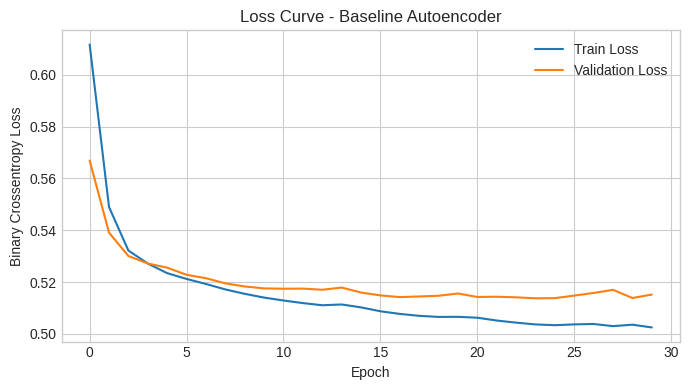

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - Baseline Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi:**

Dari kurva diketahui:
1. Model baseline telah mencapai titik konvergensi ⟶ setelah epoch diatas 15, kedua garis tidak mengalami penurunan yang signifikan. 
2. Tidak ada gap yang besar antara training dan validation loss ⟶ model cukup stabil dan tidak mengalami overfitting. 

### 3.3 Evaluasi Baseline pada Test Set — SSIM, PSNR, MSE

**Alasan memilih ketiga metrik ini:**
- **SSIM (Structural Similarity Index):** membandingkan kemiripan struktural (luminance, kontras, struktur) antara citra asli dan hasil rekonstruksi. Rentangnya `-1` s.d. `1`, makin mendekati `1` makin mirip secara struktural/persepsi visual.
- **PSNR (Peak Signal-to-Noise Ratio):** mengukur rasio antara sinyal (citra asli) terhadap noise (selisih/error rekonstruksi), dalam satuan dB, semakin tinggi semakin baik.
- **MSE (Mean Squared Error) piksel:** error rata-rata kuadrat antar piksel, metrik paling sederhana, tapi tidak menangkap kemiripan struktural seperti SSIM (dua citra bisa punya MSE kecil tapi secara visual terlihat berbeda, atau sebaliknya).

Ketiganya dilaporkan bersama karena masing-masing menyoroti aspek berbeda dari kualitas rekonstruksi; SSIM untuk persepsi/struktur, PSNR & MSE untuk akurasi piksel mentah.

In [11]:
def eval_ae(model, x_eval):
    rec = np.clip(model.predict(x_eval, verbose=0), 0, 1).astype('float32')
    ssim_score = float(tf.reduce_mean(tf.image.ssim(x_eval, rec, max_val=1.0)))
    psnr_score = float(tf.reduce_mean(tf.image.psnr(x_eval, rec, max_val=1.0)))
    mse_score  = float(np.mean((x_eval - rec) ** 2))
    return ssim_score, psnr_score, mse_score, rec


test_loss_base = ae_base.evaluate(x_test, x_test, verbose=0)
ssim_base, psnr_base, mse_base, rec_base = eval_ae(ae_base, x_test)

print(f"Baseline -> Test Loss (BCE): {test_loss_base:.5f} | SSIM: {ssim_base:.4f} | PSNR: {psnr_base:.2f} dB | MSE: {mse_base:.5f}")

Baseline -> Test Loss (BCE): 0.51458 | SSIM: 0.5298 | PSNR: 13.58 dB | MSE: 0.04605


### 3.4 Visualisasi: Citra Asli vs Hasil Rekonstruksi (Baseline)

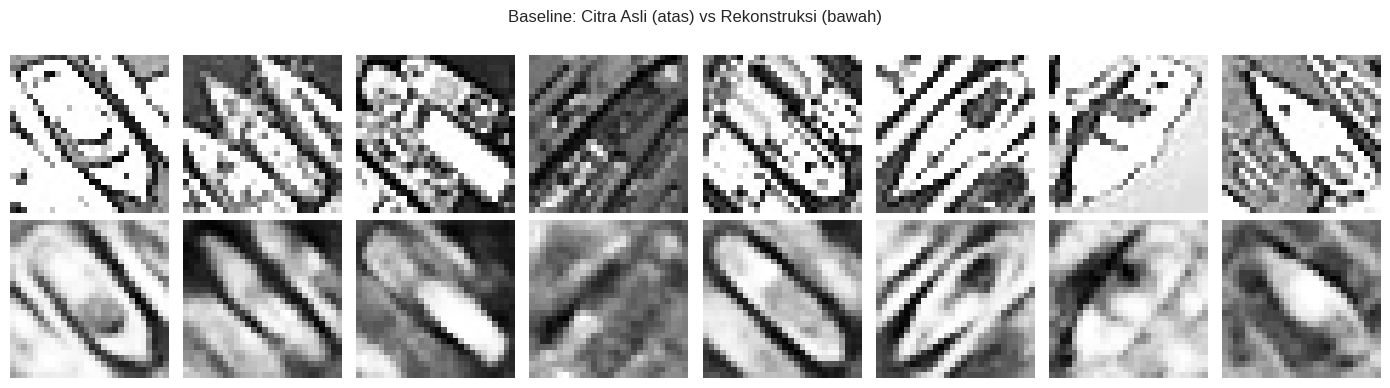

In [12]:
def plot_reconstructions(x_original, x_reconstructed, title, n=8):
    plt.figure(figsize=(14, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x_original[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel('Asli')
        plt.subplot(2, n, n + i + 1)
        plt.imshow(x_reconstructed[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_reconstructions(x_test, rec_base, "Baseline: Citra Asli (atas) vs Rekonstruksi (bawah)")

**Interpretasi:** Pada autoencoder dengan bottleneck 128 dimensi (dari 784 dimensi asli, atau rasio kompresi ±83%), hasil rekonstruksi masih bisa mengenali bentuk umum objek (siluet kapal / ship), tapi detail-detail halus (tekstur, tepi tajam) cenderung nge-blur, ini karena sebagian informasi hilang saat dikompresi ke representasi yang jauh lebih kecil.

## 4. (c) Arsitektur yang Dioptimasi + Tuning Hyperparameter

### 4.1 Modifikasi arsitektur & alasannya

| Modifikasi | Baseline | Improved | Alasan |
|---|---|---|---|
| Downsampling | `MaxPooling2D` (1 tahap, 28→14) | `Conv2D` strided (2 tahap, 28→14→7) | Mengganti “MaxPooling2D” dengan “Conv2D” ⟶ karena MaxPooling hanya mengambil nilai maksimum di setiap window secara fixed sehingga informasi yang dibuang tidak dipelajari ulang lagi. Sedangkan mengganti ke Conv2D dengan strideds=2 akan melakukan downsampling dan model tetap belajar filter terbaik untuk meringkas informasi, sehingga dapat menghasilkan rekonstruksi yang lebih baik. Downsampling 2 tahap juga membuat kompresi lebih bertahap, bkn langsung di kompres.  |
| Upsampling | `UpSampling2D` (nearest-neighbor, non-trainable) | `Conv2DTranspose` strided | Mengubah “UpSampling2D” menjadi “Conv2DTranspose”. Jika UpSampling2D hanya menduplikasi pixel tetangga, sedangkan Conv2DTranspose memiliki bobot untuk di pelajari, sehingga saat training model otomatis belajar filter terbaik untuk "mengisi" piksel kosong di antara piksel yang ada. Ini memungkinkan model menghasilkan detail tekstur yang jauh lebih kaya dan tajam daripada sekadar menyalin nilai piksel tetangga. |
| Normalisasi | Tidak ada | `BatchNormalization` setelah tiap Conv | Menambahkan BatchNormalization setelah tiap Conv. Hal ini dilakukan untuk menstabilkan dan mempercepat konvergensi. Saat melakukan upsampling dengan metode sederhana, seringkali muncul artefak pola kotak-kotak (checkerboard) pada hasil gambar karena distribusi bobot yang tidak rata saat overlapping. Saat BatchNormalization dikombinasikan dengan Conv2DTranspose dan fungsi aktivasi non-linear (leakyRelu) model dapat meredam artefak tersebut. |
| Regularisasi | Tidak ada | `Dropout` (rate menjadi salah satu parameter yang di-tuning) | Menambahkan Dropout, hal ini untuk mencegah overfitting. Karena pada plot baseline terlihat ada indikasi val_loss yang mulai mendatar sementara train_loss terus menurun.  |
| Latent dim | Fixed 128 | Di-tuning (jadi salah satu parameter pencarian) | Pada baseline di fixed 128, perubahannya kita akan tuning parameternya terlebih dahulu. Jadi kita tidak mematokkan angka 128 melainkan melakukan tuning dengan grid search untuk mencari kombinasi terbaik ⟶ karena tujuan kita untuk menghasilkan dimension reduction yang optimal. |
| Early stopping | Tidak ada | `EarlyStopping(monitor='val_loss')` | Menambahkan EarlyStopping(monitor=’val_loss’). Akan menghentikan training secara otomatis saat val_loss berhenti menurun / membaik dan mengembalikan bobot yang terbaik. 

### 4.2 Strategi tuning hyperparameter

Tuning dilakukan dengan **grid search sederhana** atas 3 hyperparameter: `learning_rate`, `latent_dim`, dan `dropout_rate`. Setiap kombinasi dilatih dengan jumlah epoch yang sengaja dibuat singkat (`TUNING_EPOCHS`, hanya untuk membandingkan arah/potensi tiap kombinasi secara adil dengan budget komputasi yang sama), lalu dipilih kombinasi dengan **validation loss terendah** sebagai konfigurasi final. Konfigurasi final ini kemudian dilatih ulang dari awal dengan jumlah epoch yang lebih besar dan `EarlyStopping` aktif, supaya benar-benar konvergen (bukan cuma "menang" di tuning yang singkat).

In [ ]:
def build_improved_ae(latent_dim=128, dropout_rate=0.2, use_batchnorm=True, final_activation='sigmoid'):
    inputs = tf.keras.Input(shape=(28, 28, 1))

    # ---- ENCODER: 2 tahap downsampling via strided Conv2D (28 -> 14 -> 7) ----
    
    # Layer 1: Deteksi fitur awal (28x28x32)
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Layer 2: Downsampling pertama (28 -> 14x14x64)
    x = layers.Conv2D(64, (3, 3), strides=2, padding='same')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
        
    # Layer 3: Downsampling kedua (14 -> 7x7x64)
    x = layers.Conv2D(64, (3, 3), strides=2, padding='same')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
        
    # Flatten & Bottleneck (Latent Space)
    x = layers.Flatten()(x)
    # Gunakan aktivasi linear atau relu pada latent space 
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    # ---- DECODER ----
    
    # Proyeksi kembali ke bentuk tensor sebelum flatten (7x7x64)
    x = layers.Dense(7 * 7 * 64)(latent)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((7, 7, 64))(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
        
    # Layer 1 Decoder: Upsampling pertama (7 -> 14x14x64)
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
        
    # Layer 2 Decoder: Upsampling kedua (14 -> 28x28x32)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Layer 3 Decoder: Rekonstruksi output akhir (28x28x1)
    # Menggunakan Conv2D untuk menghaluskan hasil bentukan Conv2DTranspose
    outputs = layers.Conv2D(1, (3, 3), padding='same', activation=final_activation)(x)

    return Model(inputs, outputs, name='improved_autoencoder')

# Test dan cetak summary struktur model
build_improved_ae().summary()

Model: "improved_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 918,529 (3.50 MB)

 Trainable params: 918,017 (3.50 MB)

 Non-trainable params: 512 (2.00 KB)

### 4.3 Tuning Hyperparameter (Grid Search Sederhana)

In [14]:
# ---- Grid hyperparameter yang dicoba (silakan ditambah/dikurangi sesuai kebutuhan) ----
TUNING_GRID = {
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'latent_dim':    [32, 64, 128],
    'dropout_rate':  [0.0, 0.2, 0.3],
}
TUNING_EPOCHS = 25  # epoch singkat khusus untuk membandingkan kandidat, BUKAN training final

tuning_results = []
for lr, ldim, drop in itertools.product(
    TUNING_GRID['learning_rate'], TUNING_GRID['latent_dim'], TUNING_GRID['dropout_rate']
):
    candidate = build_improved_ae(latent_dim=ldim, dropout_rate=drop)
    candidate.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy')

    hist = candidate.fit(
        x_train, x_train,
        validation_data=(x_val, x_val),
        epochs=TUNING_EPOCHS,
        batch_size=32,
        verbose=0
    )

    val_loss_final = hist.history['val_loss'][-1]
    tuning_results.append({
        'learning_rate': lr, 'latent_dim': ldim, 'dropout_rate': drop, 'val_loss': val_loss_final
    })
    print(f"lr={lr:<7} | latent_dim={ldim:<4} | dropout={drop:<4} -> val_loss={val_loss_final:.5f}")

tuning_df = pd.DataFrame(tuning_results).sort_values('val_loss').reset_index(drop=True)
tuning_df

lr=0.001   | latent_dim=32   | dropout=0.0  -> val_loss=0.52476
lr=0.001   | latent_dim=32   | dropout=0.2  -> val_loss=0.51345
lr=0.001   | latent_dim=32   | dropout=0.3  -> val_loss=0.51389
lr=0.001   | latent_dim=64   | dropout=0.0  -> val_loss=0.48840
lr=0.001   | latent_dim=64   | dropout=0.2  -> val_loss=0.48043
lr=0.001   | latent_dim=64   | dropout=0.3  -> val_loss=0.48188
lr=0.001   | latent_dim=128  | dropout=0.0  -> val_loss=0.45947
lr=0.001   | latent_dim=128  | dropout=0.2  -> val_loss=0.44961
lr=0.001   | latent_dim=128  | dropout=0.3  -> val_loss=0.45044
lr=0.0005  | latent_dim=32   | dropout=0.0  -> val_loss=0.51657
lr=0.0005  | latent_dim=32   | dropout=0.2  -> val_loss=0.51319
lr=0.0005  | latent_dim=32   | dropout=0.3  -> val_loss=0.51575
lr=0.0005  | latent_dim=64   | dropout=0.0  -> val_loss=0.48830
lr=0.0005  | latent_dim=64   | dropout=0.2  -> val_loss=0.48039
lr=0.0005  | latent_dim=64   | dropout=0.3  -> val_loss=0.48183
lr=0.0005  | latent_dim=128  | dropout=0

,learning_rate,latent_dim,dropout_rate,val_loss
0,0.0010,128,0.2,0.449611
1,0.0010,128,0.3,0.450438
2,0.0005,128,0.2,0.450556
3,0.0005,128,0.3,0.451454
4,0.0005,128,0.0,0.452385
5,0.0001,128,0.0,0.458214
6,0.0010,128,0.0,0.459473
7,0.0001,128,0.2,0.465279
8,0.0001,128,0.3,0.472855
9,0.0005,64,0.2,0.480391


In [15]:
best_config = tuning_df.iloc[0]
print("Konfigurasi terbaik hasil tuning:")
print(best_config)

BEST_LEARNING_RATE = float(best_config['learning_rate'])
BEST_LATENT_DIM    = int(best_config['latent_dim'])
BEST_DROPOUT_RATE  = float(best_config['dropout_rate'])

Konfigurasi terbaik hasil tuning:
learning_rate      0.001000
latent_dim       128.000000
dropout_rate       0.200000
val_loss           0.449611
Name: 0, dtype: float64


### 4.4 Training Final Model Improved

Memakai konfigurasi terbaik dari hasil tuning, dilatih ulang dari awal dengan epoch lebih banyak (`IMPROVED_EPOCHS`) dan `EarlyStopping` aktif supaya training berhenti otomatis begitu `val_loss` berhenti membaik (mencegah overfitting).

In [ ]:
# ---- Hyperparameter training final ----
IMPROVED_BATCH_SIZE     = 32
IMPROVED_EPOCHS         = 100
EARLY_STOPPING_PATIENCE = 7

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True
)

ae_improved = build_improved_ae(latent_dim=BEST_LATENT_DIM, dropout_rate=BEST_DROPOUT_RATE)
ae_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LEARNING_RATE),
    loss='binary_crossentropy'
)

history_improved = ae_improved.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    epochs=IMPROVED_EPOCHS,
    batch_size=IMPROVED_BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.5794 - val_loss: 0.5851
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5255 - val_loss: 0.5167
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5059 - val_loss: 0.4929
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4945 - val_loss: 0.4889
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4870 - val_loss: 0.4788
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4810 - val_loss: 0.4710
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4762 - val_loss: 0.4696
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4726 - val_loss: 0.4652
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4699 - val_loss: 0.4634
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4676 - val_loss: 0.4602
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4660 - val_loss: 0.4599
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━

### 4.5 Plot Train vs Validation Loss — Improved

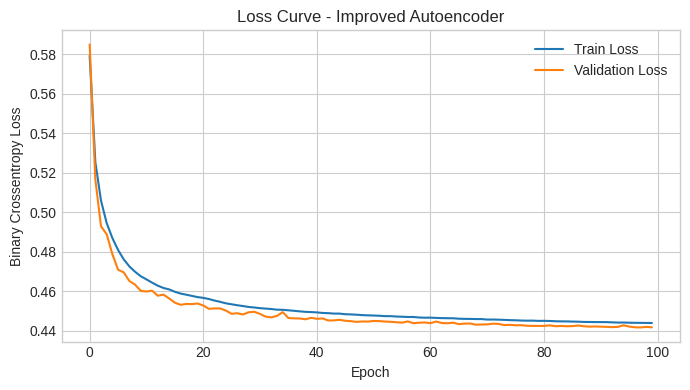

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - Improved Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

Architecture model yang diimprove, dari hasil plotting loss curvenya ⟶ dapat disimpulkan bahwa
1. model sudah konvergen dibuktikan dengan nilai train loss dan validation loss yang sama - sama menurun. secara stabil hingga mendatar. 
2. Tidak ada lagi penurunan drastis setelah sekitar epoch ke-40. Ini menandakan bahwa model telah mencapai titik optimal di mana ia tidak lagi dapat mempelajari pola baru dari data yang ada.
3. Validation Loss yang berada sedikit di bawah Training Loss terjadi karena penggunaan lapisan regularisasi (seperti Dropout) (Dropout menghukum variasi model dengan secara acak membekukan neuron di sebuah layer saat model sedang dilatih) yang aktif selama fase pelatihan namun dinonaktifkan saat fase validasi. Hal ini membuktikan bahwa model tidak mengalami overfitting dan memiliki kemampuan generalisasi yang sangat baik terhadap data yang tidak terlihat (unseen data). 

*kedepannya untuk mengetahui apakah `EarlyStopping` aktif bekerja dapat meningkatkan jumlah epoch

### 4.6 Evaluasi Improved pada Test Set

In [18]:
test_loss_improved = ae_improved.evaluate(x_test, x_test, verbose=0)
ssim_improved, psnr_improved, mse_improved, rec_improved = eval_ae(ae_improved, x_test)

print(f"Improved -> Test Loss (BCE): {test_loss_improved:.5f} | SSIM: {ssim_improved:.4f} | "
      f"PSNR: {psnr_improved:.2f} dB | MSE: {mse_improved:.5f}")

Improved -> Test Loss (BCE): 0.44230 | SSIM: 0.7957 | PSNR: 17.31 dB | MSE: 0.01985


### 4.7 Tabel Perbandingan Baseline vs Improved

In [19]:
comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline', 'Latent Dim': LATENT_DIM,
        'Test Loss (BCE)': test_loss_base, 'SSIM': ssim_base,
        'PSNR (dB)': psnr_base, 'MSE': mse_base,
    },
    {
        'Model': 'Improved', 'Latent Dim': BEST_LATENT_DIM,
        'Test Loss (BCE)': test_loss_improved, 'SSIM': ssim_improved,
        'PSNR (dB)': psnr_improved, 'MSE': mse_improved,
    },
])
comparison_df

,Model,Latent Dim,Test Loss (BCE),SSIM,PSNR (dB),MSE
0,Baseline,128,0.514579,0.529815,13.577012,0.046053
1,Improved,128,0.442299,0.795691,17.305544,0.019851


### 4.8 Visualisasi Perbandingan: Asli vs Baseline vs Improved

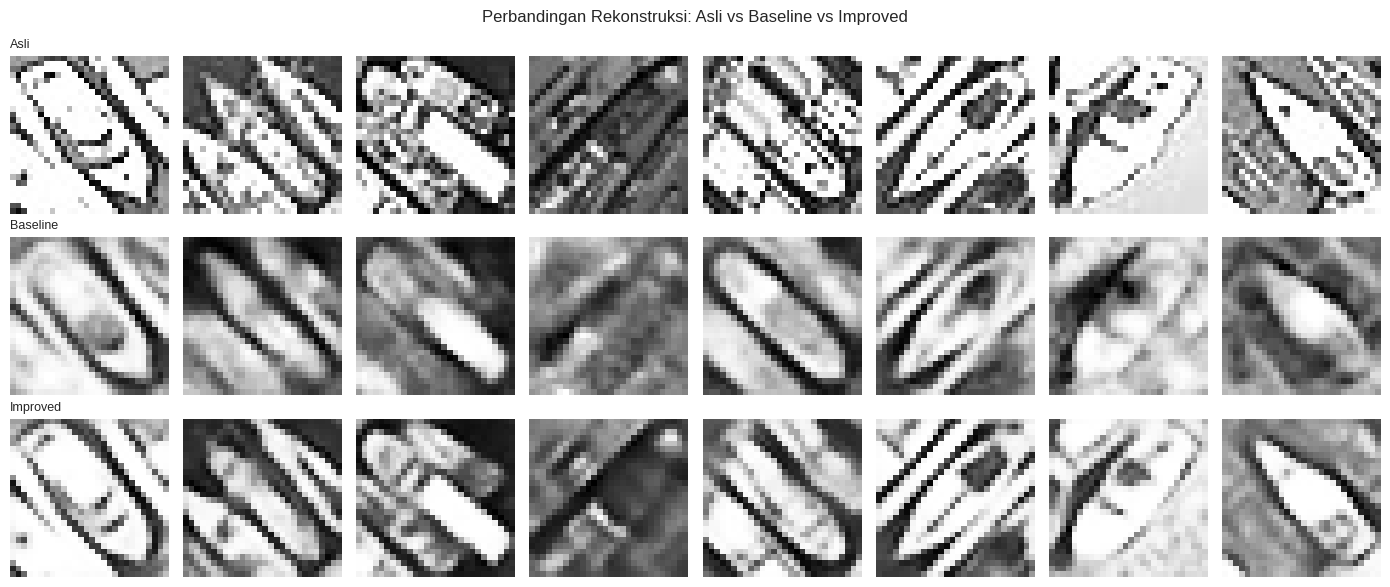

In [20]:
n = 8
plt.figure(figsize=(14, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Asli', fontsize=9, loc='left')

    plt.subplot(3, n, n + i + 1)
    plt.imshow(rec_base[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Baseline', fontsize=9, loc='left')

    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(rec_improved[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Improved', fontsize=9, loc='left')

plt.suptitle("Perbandingan Rekonstruksi: Asli vs Baseline vs Improved")
plt.tight_layout()
plt.show()

**Interpretasi:** Hasil evaluasi SSIM pada architecture baru menunjukkan adanya peningkatan ⟶ dari yang awalnya bernilai 0.52 menjadi 0.79, angka ini mengartikan bahwa output / gambar yang dihasilkan atau direkonstruksi dari model sudah 79% menyerupai input awal (luminance, kontras, struktur). Dan hasil ini diikuti oleh MSE yang semakin menurun, dan hasil PSNR yang semakin meningkat (berarti noise nya sudah berkurang walau tidak signifikan). 

Jika menggunakan mata-telanjang dapat terlihat bahwa hasil model imrpoved menghasilkan gambar dengan line / garis objek lebih tajam dibandingkan output baselinenya. 

## 5. Kesimpulan

Dari hasil evaluasi dengan training 100 epochs, dapat disimpulkan bahwa model auto-encoder improved untuk tujuan dimension reduction (dengan mengganti beberapa layer, serta menambahkan normalisasi, regularisasi, early stopping dan tuning hyperparameter) berhasil melakukan rekonstruksi dengan nilai SSIM yang mencapai 0.79 

Perbedaan utama baseline dengan architecture improved adalah menggunakan layer downsampling / upsampling yang trainable (Conv2D / Conv2DTranspose) memungkinkan model mempelajari cara terbaik untuk meringkas dan mengembalikan informasi dibandingkan operasi fixed seperti MaxPooling / UpSampling pada baseline. 